# Lab 10 – Dataset Splitting

## Objective

Prepare the dataset for deep learning by splitting the metadata into:

- Training Set
- Validation Set
- Test Set

The split will be reproducible and reusable for future model training.

### Identity-disjoint split (research objective: Real-time Lightweight Video KYC Deepfake Detection)

An earlier investigation found that a naive video-level stratified split leaks
identities: 100% of the validation identities and 100% of the test identities
also appeared in training. This is because every FaceForensics++ core
manipulation method reuses the same 500 source/target identity pairings
(1,000 identities, 500 connected components of exactly 2 identities and
12 videos each: 2 REAL + 10 FAKE).

This notebook now builds and verifies an **identity-disjoint** split instead:
whole identity-pair components are assigned to a single split
(`src/preprocessing/dataset_splitter.py`), and the separate
`DeepFakeDetection` actor namespace (28 actors / 3 components) is held out
entirely as an external generalization evaluation set rather than being
folded into train/validation/test.

In [1]:
# Clone repository

import os

os.chdir("/content")

!rm -rf Deepfake-Detection-KYC

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 165 (delta 82), reused 101 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 3.15 MiB | 19.20 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/Deepfake-Detection-KYC


In [2]:
from pathlib import Path

print(Path.cwd())

!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [3]:
!pip install -q kaggle pandas numpy matplotlib opencv-python tqdm

In [4]:
import os
from getpass import getpass

print("Configure Kaggle")

os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass("API Token: ")

print("Kaggle configured")

Configure Kaggle
Username: shreyamaurya07
API Token: ··········
Kaggle configured


In [5]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [6]:
!kaggle datasets list -s faceforensics

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4869         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          56975        107  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000           9029         26  0.3125  

In [7]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [12:02<00:00, 24.8MB/s]



In [8]:
!ls -lh

total 17G
drwxr-xr-x 6 root root 4.0K Aug  3 20:07 data
drwxr-xr-x 2 root root 4.0K Aug  3 20:07 docs
-rw-r--r-- 1 root root  218 Aug  3 20:07 environment.yml
-rw-r--r-- 1 root root  17G Dec  7  2024 ff-c23.zip
drwxr-xr-x 2 root root 4.0K Aug  3 20:07 notebooks
drwxr-xr-x 6 root root 4.0K Aug  3 20:07 outputs
drwxr-xr-x 2 root root 4.0K Aug  3 20:07 presentations
-rw-r--r-- 1 root root  960 Aug  3 20:07 README.md
drwxr-xr-x 2 root root 4.0K Aug  3 20:07 reports
-rw-r--r-- 1 root root   81 Aug  3 20:07 requirements.txt
drwxr-xr-x 8 root root 4.0K Aug  3 20:07 src


In [9]:
!mkdir -p data/raw

In [10]:
!unzip -q ff-c23.zip -d data/raw/

In [11]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/NeuralTextures
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/csv


In [12]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 10.0 MB/s eta 0:00:00


In [13]:
import cv2
print(cv2.__version__)

4.10.0


In [15]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

In [16]:
PROJECT_ROOT = Path.cwd()

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "FaceForensics++_C23"

METADATA_FILE = PROJECT_ROOT / "data" / "metadata" / "master_metadata.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "splits"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Metadata File:")
print(METADATA_FILE)

print()

print("Output Directory:")
print(OUTPUT_DIR)

Metadata File:
/content/Deepfake-Detection-KYC/data/metadata/master_metadata.csv

Output Directory:
/content/Deepfake-Detection-KYC/data/splits


In [19]:
!find /content/Deepfake-Detection-KYC/src/preprocessing -name "read_metadata.py"

/content/Deepfake-Detection-KYC/src/preprocessing/read_metadata.py


In [20]:
%cd /content/Deepfake-Detection-KYC

!python src/preprocessing/read_metadata.py

/content/Deepfake-Detection-KYC
Reading original.csv...
Reading Deepfakes.csv...
Reading FaceSwap.csv...
Reading Face2Face.csv...
Reading FaceShifter.csv...
Reading NeuralTextures.csv...
Reading DeepFakeDetection.csv...

Successfully merged all CSV files.
Metadata cleaned successfully.

Metadata saved successfully!
Location: /content/Deepfake-Detection-KYC/data/metadata/master_metadata.csv

Metadata Engineering Completed Successfully!


In [21]:
!ls data/metadata

master_metadata.csv


In [22]:
metadata = pd.read_csv(METADATA_FILE)

print("Total Samples:", len(metadata))

metadata.head()

Total Samples: 7000


,File Path,Label,Frame Count,Width,Height
0,original/000.mp4,REAL,396,640,480
1,original/001.mp4,REAL,460,1280,720
2,original/002.mp4,REAL,693,1280,720
3,original/003.mp4,REAL,303,640,480
4,original/004.mp4,REAL,309,1280,720


Label
FAKE    6000
REAL    1000
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution'}, xlabel='Label'>

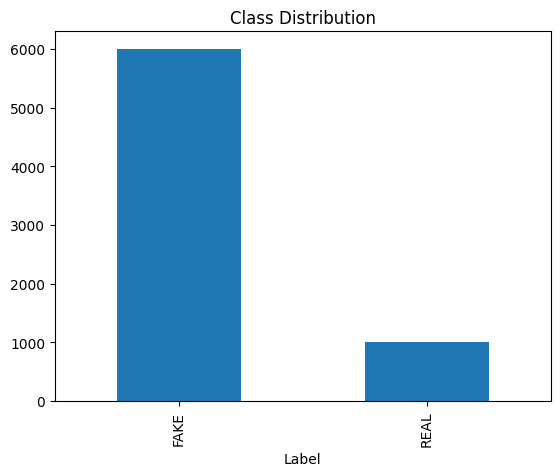

In [23]:
label_counts = metadata["Label"].value_counts()

print(label_counts)

label_counts.plot(kind="bar", title="Class Distribution")


## Identity-Disjoint Split: Build, Save, and Verify

Steps below:

1. Pull the latest `dataset_splitter.py` (in case this Colab session cloned
   the repo before the identity-disjoint split was added).
2. Namespace-aware identity parsing demo (`core` vs `dfd`).
3. Build the core identity-pair graph (union-find) and the DFD actor graph.
4. Build the identity-disjoint split (seed = 42).
5. Run strong validation checks that fail loudly on any leakage.
6. Print videos/labels/identities/groups per split, the identity overlap
   matrix, and the DFD held-out count.
7. Explicit assertions for the exact expected counts.
8. Save the splits and reload them from disk to confirm.

In [ ]:
%cd /content/Deepfake-Detection-KYC
!git pull origin main

In [ ]:
from src.preprocessing.dataset_splitter import (
    parse_identity,
    build_core_identity_groups,
    build_dfd_actor_groups,
    split_dataset_identity_disjoint,
    validate_identity_disjoint_split,
    compute_identity_overlap_matrix,
    summarize_identity_split,
    save_splits,
    get_split_summary,
)

metadata = pd.read_csv(METADATA_FILE)

# Namespace-aware parsing demo
for sample_path in [
    "original/000.mp4",
    "Deepfakes/000_003.mp4",
    "DeepFakeDetection/01_02__meeting_serious__YVGY8LOK.mp4",
]:
    print(sample_path, "->", parse_identity(sample_path))

In [ ]:
core_groups = build_core_identity_groups(metadata)
dfd_groups = build_dfd_actor_groups(metadata)

core_group_sizes = sorted(len(members) for members in core_groups.values())
dfd_group_sizes = sorted(len(members) for members in dfd_groups.values())

print("Core identity-pair groups (connected components):", len(core_groups))
print("Core group sizes (identities per group):", set(core_group_sizes))
print()
print("DFD actor groups (connected components):", len(dfd_groups))
print("DFD component sizes:", dfd_group_sizes)

In [ ]:
train_df, val_df, test_df, dfd_df, report = split_dataset_identity_disjoint(
    metadata,
    random_state=42,
)

print("train/validation/test/DFD row counts:")
print(len(train_df), len(val_df), len(test_df), len(dfd_df))

In [ ]:
# Fails loudly (raises SplitValidationError) on ANY of:
#   - a File Path in more than one split
#   - a core identity in more than one split
#   - a core group in more than one split
#   - a missing or duplicated core group
#   - DFD rows inside train/validation/test
#   - wrong group/video/REAL/FAKE counts
validate_identity_disjoint_split(train_df, val_df, test_df, dfd_df)
print("validate_identity_disjoint_split: ALL CHECKS PASSED")

In [ ]:
summary = summarize_identity_split(train_df, val_df, test_df, dfd_df)

print("Videos per split:")
print(summary["videos_per_split"])
print()
print("REAL/FAKE counts per split:")
for split_name, counts in summary["label_counts_per_split"].items():
    print(f"  {split_name}: {counts}")

In [ ]:
print("Unique core identities per split:")
print(summary["unique_identities_per_split"])
print()
print("Identity overlap matrix (off-diagonal MUST be 0):")
overlap_matrix = summary["identity_overlap_matrix"]
print(overlap_matrix)

In [ ]:
print("Core identity groups per split:")
print(summary["groups_per_split"])
print()
print("DeepFakeDetection held-out count:", summary["dfd_video_count"])
print("DeepFakeDetection label counts:", summary["dfd_label_counts"])

In [ ]:
# Explicit checks for the exact expected identity-disjoint split.

assert overlap_matrix.loc["train", "validation"] == 0
assert overlap_matrix.loc["train", "test"] == 0
assert overlap_matrix.loc["validation", "test"] == 0
print("Identity overlap: train & validation = train & test = validation & test = 0 (no shared identities)")

assert summary["groups_per_split"] == {"train": 350, "validation": 75, "test": 75}
print("Core groups per split: train=350, validation=75, test=75")

assert summary["videos_per_split"] == {"train": 4200, "validation": 900, "test": 900}
print("Core split video counts: train=4200, validation=900, test=900")

assert summary["label_counts_per_split"]["train"] == {"FAKE": 3500, "REAL": 700}
assert summary["label_counts_per_split"]["validation"] == {"FAKE": 750, "REAL": 150}
assert summary["label_counts_per_split"]["test"] == {"FAKE": 750, "REAL": 150}
print("REAL/FAKE counts: train 700/3500, validation 150/750, test 150/750")

assert summary["dfd_video_count"] == 1000
assert summary["dfd_label_counts"] == {"FAKE": 1000}
print("DFD held-out: 1000 FAKE")

print("\nAll Lab 10 verification checks passed.")

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

save_splits(
    train_df,
    val_df,
    test_df,
    OUTPUT_DIR,
    dfd_df=dfd_df,
)

final_summary = get_split_summary(train_df, val_df, test_df, dfd_df=dfd_df)
print("Saved identity-disjoint splits:")
print(final_summary)

In [ ]:
import os

print(os.listdir(OUTPUT_DIR))
print()

for csv_name in [
    "train.csv",
    "validation.csv",
    "test.csv",
    "deepfakedetection_test.csv",
]:
    reloaded = pd.read_csv(OUTPUT_DIR / csv_name)
    print(csv_name, "->", len(reloaded), "rows")
    print(reloaded.head(2))
    print()